## DS Lab Session 5: Graded Assignment

Nandan M  
15/11/2025

### Problem Statements:
1. Drop Date and Date ID from the Dataset
2. Compute the number of days with Fog, Partly cloudy, Broken clouds, Drizzle and plot the bar graph.
3. Compute the average temperature in each year and plot the results as average temperature vs year.
4. Plot histogram for humidity
5. Plot freq polygon of humidity and temp like above for each year.
6. Compute Mode value desc.
7. Convert day name as 0: sunday 1: Monday and so on.
8. Plot average temperature on Sundays,
9. Plot a pie chart for barometer value <1001 on sundays.
10. Plot which date and month has more reading in each year.

Dataset: https://www.kaggle.com/datasets/jkrithika/chennai-2009-2024-weather-data

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download('jkrithika/chennai-2009-2024-weather-data')
dataset_input_path = os.path.join(path, 'Clean15YearChennaiWeather.csv')

In [3]:
# Read and Load as dataframe
raw_data_df = pd.read_csv(dataset_input_path)
raw_data_df.head()

,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
0,"Sunday 14 July 2024, 18.00 — 00.00",1.720980e+12,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,18:00,00:00
1,"Monday 15 July 2024, 00.00 — 06.00",1.721002e+12,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,00:00,06:00
2,"Monday 15 July 2024, 06.00 — 12.00",1.721023e+12,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,06:00,12:00
3,"Monday 15 July 2024, 12.00 — 18.00",1.721045e+12,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,12:00,18:00
4,"Monday 15 July 2024, 18.00 — 00.00",1.721066e+12,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,18:00,00:00


#### Exploring dataset
Start by seeing data types, and simple stats on all samples

In [4]:
# check no of sample, datatypes of each column
raw_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1068 non-null   object 
 1   date_id     1068 non-null   float64
 2   wind        1068 non-null   float64
 3   desc        1068 non-null   object 
 4   temp        1038 non-null   float64
 5   baro        1068 non-null   float64
 6   hum         1068 non-null   int64  
 7   day         1068 non-null   object 
 8   month       1068 non-null   int64  
 9   day_date    1068 non-null   int64  
 10  year        1068 non-null   int64  
 11  day_name    1068 non-null   int64  
 12  Start_hour  1068 non-null   object 
 13  End_hour    1068 non-null   object 
dtypes: float64(4), int64(5), object(5)
memory usage: 116.9+ KB


In [5]:
# check for unique values in each column
raw_data_df.nunique()

date          641
date_id       641
wind           23
desc           29
temp           18
baro           25
hum            62
day           161
month           6
day_date       31
year            3
day_name        7
Start_hour      4
End_hour        4
dtype: int64

In [6]:
# get statistical summary of the dataset
raw_data_df.describe(include='all')

,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
count,1068,1.068000e+03,1068.000000,1068,1038.000000,1068.000000,1068.000000,1068,1068.000000,1068.000000,1068.000000,1068.000000,1068,1068
unique,641,NaN,NaN,29,NaN,NaN,NaN,161,NaN,NaN,NaN,NaN,4,4
top,"Sunday 14 July 2024, 18.00 — 00.00",NaN,NaN,Passing clouds.,NaN,NaN,NaN,2024-07-15,NaN,NaN,NaN,NaN,18:00,00:00
freq,8,NaN,NaN,226,NaN,NaN,NaN,32,NaN,NaN,NaN,NaN,273,273
mean,NaN,1.470229e+12,11.558052,NaN,30.314066,978.586142,72.743446,NaN,7.846442,18.913858,2015.970037,2.951311,NaN,NaN
std,NaN,2.307234e+11,6.947885,NaN,3.542770,166.914996,17.154781,NaN,3.089847,7.536483,7.375270,2.042076,NaN,NaN
min,NaN,1.252454e+12,0.000000,NaN,21.000000,0.000000,0.000000,NaN,1.000000,1.000000,2009.000000,0.000000,NaN,NaN
25%,NaN,1.258216e+12,5.000000,NaN,28.000000,1003.000000,66.000000,NaN,7.000000,15.000000,2009.000000,1.000000,NaN,NaN
50%,NaN,1.263978e+12,13.000000,NaN,30.000000,1006.000000,74.000000,NaN,7.000000,20.000000,2010.000000,3.000000,NaN,NaN
75%,NaN,1.721563e+12,18.000000,NaN,34.000000,1012.000000,84.000000,NaN,10.000000,25.000000,2024.000000,5.000000,NaN,NaN


In [7]:
# check for duplicate rows
raw_data_df.duplicated().sum()


np.int64(427)

427 duplicate rows found, need to be removed.

In [8]:
# check invalid values in main feature columns
# as we found during initial observation, temp has NaN values, hum and baro has 0 values
invalid_data_df = raw_data_df[raw_data_df['temp'].isna() | (raw_data_df['hum'] == 0) | (raw_data_df['baro'] == 0)]
print(len(invalid_data_df))
invalid_data_df

30


,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
491,"Wednesday 9 September 2009, 18.00 — 00.00",1.252519e+12,0.0,No weather data available,NaN,0.0,0,2009-09-09,9,9,2009,2,18:00,00:00
552,"Friday 25 September 2009, 00.00 — 06.00",1.253837e+12,0.0,No weather data available,NaN,0.0,0,2009-09-25,9,25,2009,4,00:00,06:00
583,"Friday 2 October 2009, 18.00 — 00.00",1.254506e+12,0.0,No weather data available,NaN,0.0,0,2009-10-02,10,2,2009,4,18:00,00:00
584,"Saturday 3 October 2009, 00.00 — 06.00",1.254528e+12,0.0,No weather data available,NaN,0.0,0,2009-10-03,10,3,2009,5,00:00,06:00
585,"Saturday 3 October 2009, 06.00 — 12.00",1.254550e+12,0.0,No weather data available,NaN,0.0,0,2009-10-03,10,3,2009,5,06:00,12:00
586,"Saturday 3 October 2009, 12.00 — 18.00",1.254571e+12,0.0,No weather data available,NaN,0.0,0,2009-10-03,10,3,2009,5,12:00,18:00
587,"Saturday 3 October 2009, 18.00 — 00.00",1.254593e+12,0.0,No weather data available,NaN,0.0,0,2009-10-03,10,3,2009,5,18:00,00:00
588,"Sunday 4 October 2009, 00.00 — 06.00",1.254614e+12,0.0,No weather data available,NaN,0.0,0,2009-10-04,10,4,2009,6,00:00,06:00
589,"Sunday 4 October 2009, 06.00 — 12.00",1.254636e+12,0.0,No weather data available,NaN,0.0,0,2009-10-04,10,4,2009,6,06:00,12:00
590,"Sunday 4 October 2009, 12.00 — 18.00",1.254658e+12,0.0,No weather data available,NaN,0.0,0,2009-10-04,10,4,2009,6,12:00,18:00


Found 30 rows with NaN in 'temp' column, and some rows with 0 in 'hum' and 'baro' columns. These rows will be removed as they are invalid for weather data.

#### Data Cleaning

In [9]:
# remove duplicate rows
clean_df = raw_data_df.drop_duplicates() # this by default keeps first occurrence

clean_df.duplicated().sum() # check again

np.int64(0)

In [10]:
# remove rows with NaN in 'temp' column
# remove rows with 0 in 'hum' and 'baro' columns
# since this weather data is of chennai, india - a tropical city
# hum and baro cannot be 0 in real world scenario, hence removing such rows
clean_df = clean_df[clean_df['temp'].notna() & (clean_df['hum'] > 0) & (clean_df['baro'] > 0)]

In [11]:
clean_df.info()
clean_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 611 entries, 0 to 1067
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        611 non-null    object 
 1   date_id     611 non-null    float64
 2   wind        611 non-null    float64
 3   desc        611 non-null    object 
 4   temp        611 non-null    float64
 5   baro        611 non-null    float64
 6   hum         611 non-null    int64  
 7   day         611 non-null    object 
 8   month       611 non-null    int64  
 9   day_date    611 non-null    int64  
 10  year        611 non-null    int64  
 11  day_name    611 non-null    int64  
 12  Start_hour  611 non-null    object 
 13  End_hour    611 non-null    object 
dtypes: float64(4), int64(5), object(5)
memory usage: 71.6+ KB


,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
count,611,6.110000e+02,611.000000,611,611.000000,611.000000,611.000000,611,611.000000,611.000000,611.000000,611.000000,611,611
unique,611,NaN,NaN,28,NaN,NaN,NaN,158,NaN,NaN,NaN,NaN,4,4
top,"Sunday 14 July 2024, 18.00 — 00.00",NaN,NaN,Passing clouds.,NaN,NaN,NaN,2024-07-15,NaN,NaN,NaN,NaN,00:00,06:00
freq,1,NaN,NaN,205,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,154,154
mean,NaN,1.305056e+12,8.013093,NaN,28.963993,1009.710311,77.980360,NaN,8.310966,17.469722,2010.700491,3.013093,NaN,NaN
std,NaN,1.388876e+11,6.000259,NaN,3.628487,15.940346,13.262159,NaN,3.954022,8.285499,4.450491,1.990920,NaN,NaN
min,NaN,1.252454e+12,0.000000,NaN,21.000000,672.000000,37.000000,NaN,1.000000,1.000000,2009.000000,0.000000,NaN,NaN
25%,NaN,1.256072e+12,3.000000,NaN,26.000000,1008.000000,68.000000,NaN,7.000000,11.000000,2009.000000,1.000000,NaN,NaN
50%,NaN,1.259690e+12,7.000000,NaN,28.000000,1012.000000,80.000000,NaN,10.000000,18.000000,2009.000000,3.000000,NaN,NaN
75%,NaN,1.262984e+12,12.000000,NaN,31.000000,1014.000000,89.000000,NaN,11.000000,24.000000,2010.000000,5.000000,NaN,NaN


#### Observations: From an initial look

1. Found many duplicate rows, removed.
2. Data missing in `temp` column (missing 30 samples) - examining further found there no other columns data as well for those samples. removed.
3. For some samples `baro`(barometer) and `hum`(humidity) is 0. removed.
4. All column's values seems to be within the valid range

## 1. Drop Date and Date ID from the Dataset

`date` and `date_id` are redundant, it can be reproduced by other columns `day`, `day_date`, `month` and `year`

In [12]:
clean_df = clean_df.drop(['date', 'date_id'], axis=1)
clean_df.head()

,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
0,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,18:00,00:00
1,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,00:00,06:00
2,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,06:00,12:00
3,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,12:00,18:00
4,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,18:00,00:00


## 2. Compute the number of days with Fog, Partly cloudy, Broken clouds, Drizzle and plot the bar graph.

considering each value as independent in the dataset

In [13]:
# this data is in desc as string, need to split by '.'
clean_df['desc_list'] = (
    clean_df['desc']
    .str.split('.')
    .apply(lambda x: [i.strip() for i in x if i.strip() != ''])
)
clean_df.head()

,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour,desc_list
0,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,18:00,00:00,"[Drizzle, Fog]"
1,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,00:00,06:00,[Fog]
2,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,06:00,12:00,"[Drizzle, Broken clouds]"
3,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,12:00,18:00,"[Drizzle, Broken clouds]"
4,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,18:00,00:00,[Fog]


In [14]:
# now make it into each columns to represent as a feature, with boolean 0, 1 for its presence
clean_df = clean_df.join(
    clean_df['desc_list']
    .str.join('|')
    .str.get_dummies()
    .astype(int)
)
clean_df.head()

,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,...,Overcast,Partly cloudy,Partly sunny,Passing clouds,Rain,Scattered clouds,Smoke,Sunny,Thundershowers,Thunderstorms
0,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,...,0,0,0,0,0,0,0,0,0,0
1,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,...,0,0,0,0,0,0,0,0,0,0
2,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,...,0,0,0,0,0,0,0,0,0,0
3,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,...,0,0,0,0,0,0,0,0,0,0
4,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
# sanity check for columns and datatypes
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 611 entries, 0 to 1067
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   wind                  611 non-null    float64
 1   desc                  611 non-null    object 
 2   temp                  611 non-null    float64
 3   baro                  611 non-null    float64
 4   hum                   611 non-null    int64  
 5   day                   611 non-null    object 
 6   month                 611 non-null    int64  
 7   day_date              611 non-null    int64  
 8   year                  611 non-null    int64  
 9   day_name              611 non-null    int64  
 10  Start_hour            611 non-null    object 
 11  End_hour              611 non-null    object 
 12  desc_list             611 non-null    object 
 13  Broken clouds         611 non-null    int64  
 14  Clear                 611 non-null    int64  
 15  Drizzle               611 n

In [16]:
# based on unique date, get counts of selected feature samples
cols = ['Fog', 'Partly cloudy', 'Broken clouds', 'Drizzle']
feat_1_df = (
    clean_df.groupby('day', as_index=False)
      .agg({
          col_name: 'max'  # <-- presence of feature in that day hence not doing sum, since multiple samples per day
       for col_name in cols })
)


In [17]:
# checking how many days these weather condition are found
feat_1_df[cols].sum()

Fog              47
Partly cloudy    43
Broken clouds    57
Drizzle          13
dtype: int64

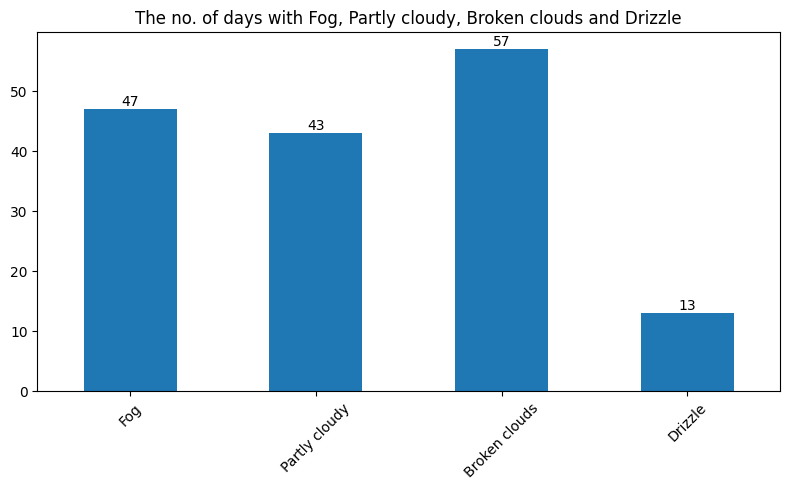

In [18]:
# plot bar chart

feat_1_counts = feat_1_df[cols].sum()

ax = feat_1_counts.plot(kind='bar', figsize=(8,5),
                     title='The no. of days with Fog, Partly cloudy, Broken clouds and Drizzle')

# add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(str(height),
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
clean_df.columns

Index(['wind', 'desc', 'temp', 'baro', 'hum', 'day', 'month', 'day_date',
       'year', 'day_name', 'Start_hour', 'End_hour', 'desc_list',
       'Broken clouds', 'Clear', 'Drizzle', 'Fog', 'Haze', 'Light rain',
       'More clouds than sun', 'Mostly cloudy', 'Overcast', 'Partly cloudy',
       'Partly sunny', 'Passing clouds', 'Rain', 'Scattered clouds', 'Smoke',
       'Sunny', 'Thundershowers', 'Thunderstorms'],
      dtype='object')

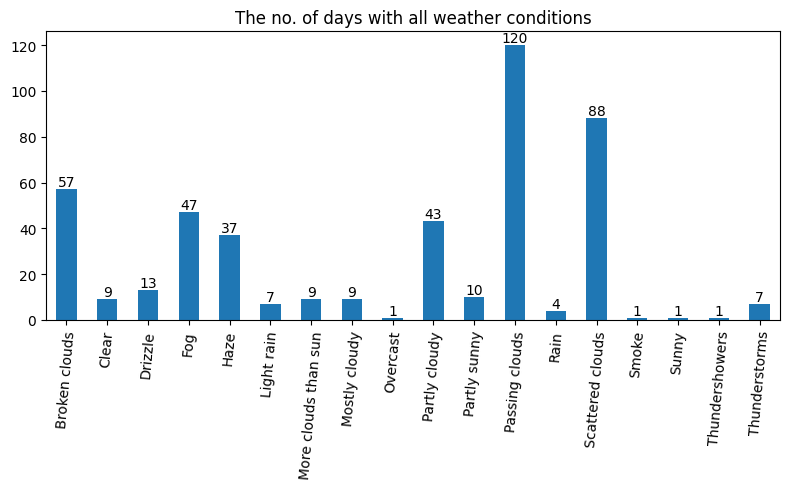

In [20]:
cols_2 = ['Broken clouds', 'Clear', 'Drizzle', 'Fog', 'Haze', 'Light rain',
       'More clouds than sun', 'Mostly cloudy', 
       'Overcast', 'Partly cloudy', 'Partly sunny', 'Passing clouds', 'Rain',
       'Scattered clouds', 'Smoke', 'Sunny', 'Thundershowers',
       'Thunderstorms']
feat_2_df = (
    clean_df.groupby('day', as_index=False)
      .agg({
          col_name: 'max'
       for col_name in cols_2 })
)
feat_2_counts = feat_2_df[cols_2].sum()

ax = feat_2_counts.plot(kind='bar', figsize=(8,5),
                     title='The no. of days with all weather conditions')

# add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(str(height),
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')

plt.xticks(rotation=85)
plt.tight_layout()
plt.show()



## 3. Compute the average temperature in each year and plot the results as average temperature vs year.

In [21]:
# check all unique years available
clean_df['year'].unique()

array([2024, 2009, 2010])

In [22]:
# check valid temp range
clean_df['temp'].describe()

count    611.000000
mean      28.963993
std        3.628487
min       21.000000
25%       26.000000
50%       28.000000
75%       31.000000
max       38.000000
Name: temp, dtype: float64

In [23]:
clean_df['temp'].isna().sum()

np.int64(0)

In [24]:
# calculate avg temp per year
avg_temp_per_year_df = (clean_df.groupby('year', as_index=False).agg({'temp':'mean'}))
avg_temp_per_year_df

,year,temp
0,2009,29.152582
1,2010,26.701613
2,2024,32.245902


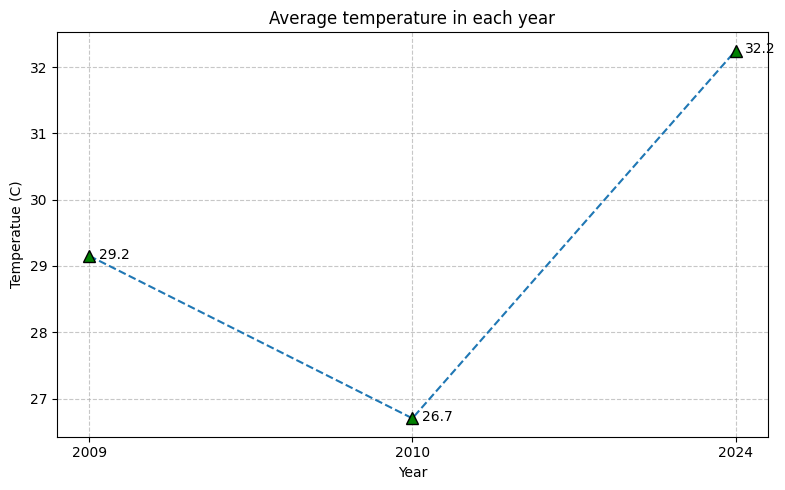

In [25]:
# plot line chart
years = avg_temp_per_year_df['year'].astype(str)
temps = avg_temp_per_year_df['temp']


plt.figure(figsize=(8,5))
plt.plot(
    years.astype(str),
    temps,
    marker='^',
    linestyle='--',
    markerfacecolor='green',
    markeredgecolor="black",
    markersize=8
)

for x, y in zip(years, temps):
    plt.annotate(
        str(round(float(y),1)),
        (x, y),
        textcoords="offset points",
        xytext=(18, -2), 
        ha='center'
    )
plt.xlabel('Year')
plt.ylabel('Temperatue (C)')
plt.title('Average temperature in each year')

plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 4. Plot histogram for humidity

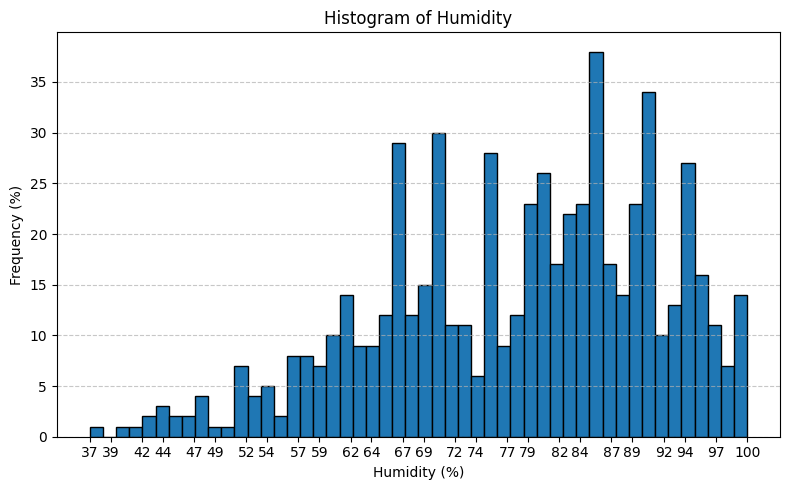

In [26]:
humidity_df = clean_df['hum']

plt.figure(figsize=(8,5))
# chose higher number of bins for better granularity
_, bins, _ = plt.hist(humidity_df, bins=50, edgecolor='black') # since bins are used, did not print labels on top of bars
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency (%)')
plt.title('Histogram of Humidity')
plt.xticks([int(b) for b in bins[::2]])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 5. Plot freq polygon of humidity and temp like above for each year.

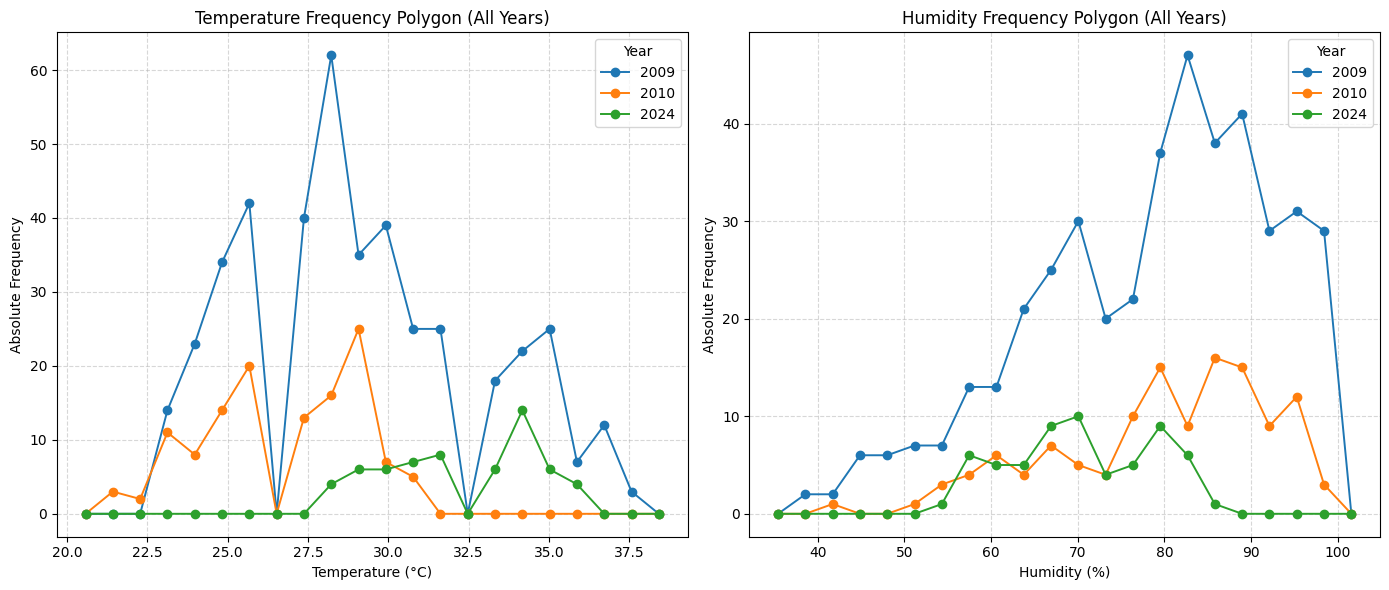

In [27]:
years = sorted(clean_df['year'].unique())

def freq_polygon(ax, data, bin_edges, label=None):
    counts, _ = np.histogram(data, bins=bin_edges)

    mids = (bin_edges[:-1] + bin_edges[1:]) / 2

    step = mids[1] - mids[0] # for clean visualization

    # extend point to zero so shape is complete across x-axis
    mids_ext = np.concatenate(([mids[0] - step], mids, [mids[-1] + step]))
    counts_ext = np.concatenate(([0], counts, [0]))

    ax.plot(mids_ext, counts_ext, marker='o', linewidth=1.4, label=label)


temp_data = clean_df['temp']
hum_data = clean_df['hum']

temp_bins = np.linspace(temp_data.min(), temp_data.max(), 21)
hum_bins = np.linspace(hum_data.min(), hum_data.max(), 21)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Temperature
for yr in years:
    freq_polygon(axes[0], clean_df.loc[clean_df['year'] == yr, 'temp'], temp_bins, label=str(yr))
axes[0].set_title("Temperature Frequency Polygon (All Years)")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Absolute Frequency")
axes[0].grid(linestyle='--', alpha=0.5)
axes[0].legend(title="Year")

# Humidity
for yr in years:
    freq_polygon(axes[1], clean_df.loc[clean_df['year'] == yr, 'hum'], hum_bins, label=str(yr))
axes[1].set_title("Humidity Frequency Polygon (All Years)")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("Absolute Frequency")
axes[1].grid(linestyle='--', alpha=0.5)
axes[1].legend(title="Year")

plt.tight_layout()
plt.show()

## 6. Compute Mode value desc.

In [28]:
# Mode value of desc
desc_df = clean_df['desc']
desc_df.mode()


0    Passing clouds.
Name: desc, dtype: object

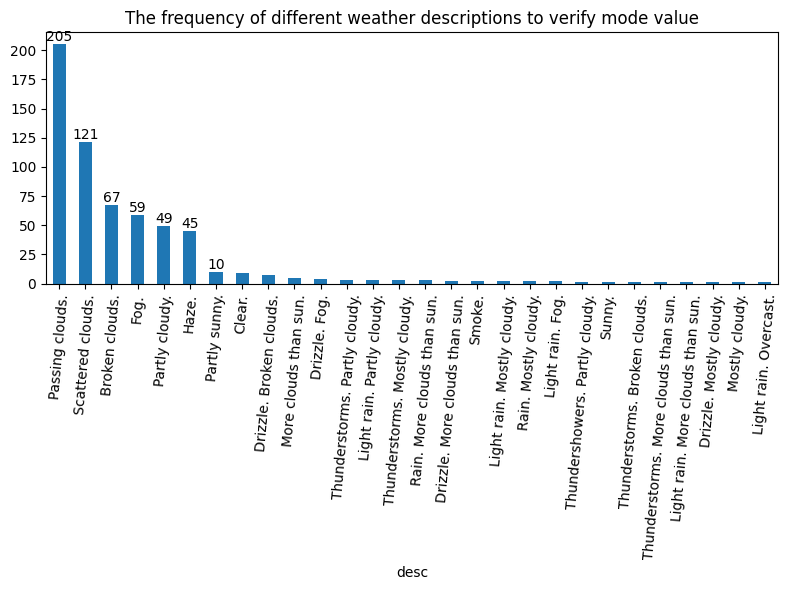

In [29]:
# verify above mode value by plotting frequency of all desc values
desc_freq_counts = desc_df.value_counts()

ax = desc_freq_counts.plot(kind='bar', figsize=(8,6),
                     title='The frequency of different weather descriptions to verify mode value')

# add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height < 10:
        continue
    ax.annotate(str(height),
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()

## 7. Convert day name as 6: sunday 0: Monday and so on.
As per dataset, day name starts with Monday as 0, so converting accordingly

In [30]:
clean_df['day_name'].unique()

array([6, 0, 1, 2, 3, 4, 5])

In [31]:
day_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
clean_df['day_name'] = clean_df['day_name'].replace(day_map)
clean_df.head()

,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,...,Overcast,Partly cloudy,Partly sunny,Passing clouds,Rain,Scattered clouds,Smoke,Sunny,Thundershowers,Thunderstorms
0,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,Sunday,...,0,0,0,0,0,0,0,0,0,0
1,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,Monday,...,0,0,0,0,0,0,0,0,0,0
2,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,Monday,...,0,0,0,0,0,0,0,0,0,0
3,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,Monday,...,0,0,0,0,0,0,0,0,0,0
4,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,Monday,...,0,0,0,0,0,0,0,0,0,0


## 8. Plot average temperature on Sundays,

In [32]:
clean_df[['month','year']].nunique()

month    6
year     3
dtype: int64

In [33]:
sunday_df = clean_df[clean_df['day_name']=='Sunday']
avg_temp_per_month_df = (clean_df.groupby(['month','year'], as_index=False).agg({'temp':'mean'}))
avg_temp_per_month_df

,month,year,temp
0,1,2010,26.701613
1,7,2024,32.245902
2,9,2009,32.418605
3,10,2009,31.261261
4,11,2009,27.561905
5,12,2009,26.346774


In [34]:
# average of all sundays
float(round(sunday_df['temp'].mean(),2))

28.59

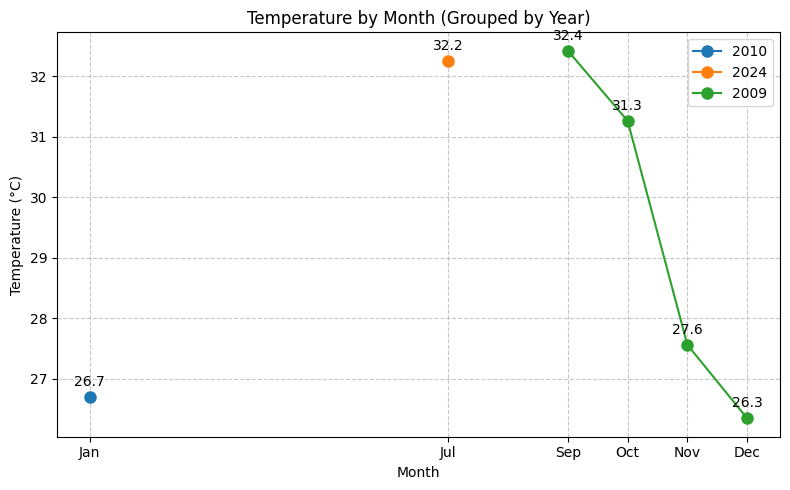

In [35]:
plt.figure(figsize=(8,5))

for yr in avg_temp_per_month_df['year'].unique():
    sub = avg_temp_per_month_df[avg_temp_per_month_df['year'] == yr]
    plt.plot(
        sub['month'],
        sub['temp'],
        marker='o',
        linestyle='-',
        markersize=8,
        label=str(yr)
    )
    # annotate
    for x, y in zip(sub['month'], sub['temp']):
        plt.annotate(
            str(round(float(y),1)),
            (x, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha='center'
        )

month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}
month_df = avg_temp_per_month_df['month']
plt.xticks(month_df, [month_map[m] for m in month_df])

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Temperature by Month (Grouped by Year)")
plt.grid(linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


## 9. Plot a pie chart for barometer value <1001 on sundays.

In [36]:
sunday_df = clean_df[clean_df['day_name']=='Sunday']

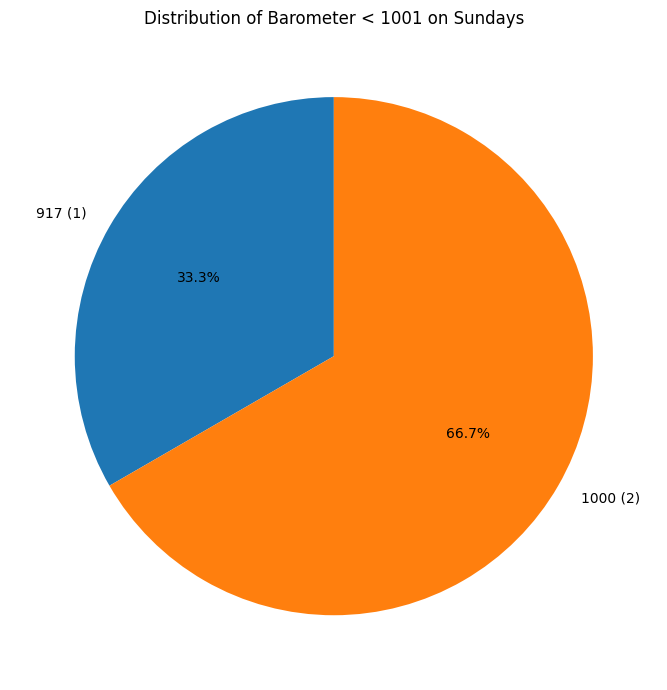

In [37]:
low_baro = sunday_df[sunday_df['baro'] < 1001]

# Frequency distribution
counts = low_baro['baro'].value_counts().sort_index()
labels = counts.index.astype(int).astype(str)

plt.figure(figsize=(7,7))

labels_with_counts = [f"{lab} ({cnt})" for lab, cnt in zip(labels, counts.values)]
plt.pie(
    counts.values,
    labels=labels_with_counts,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Barometer < 1001 on Sundays")
plt.tight_layout()
plt.show()

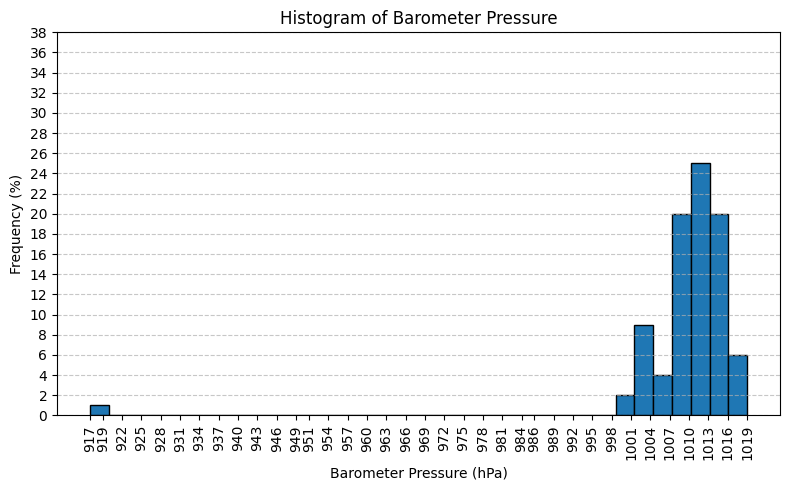

In [38]:
# verifying above pie chart by plotting histogram of barometer values on sundays
baro_sunday_df = sunday_df['baro']

plt.figure(figsize=(8,5))
# chose higher number of bins for better granularity
_, bins, _ = plt.hist(baro_sunday_df, bins=35, edgecolor='black') # since bins are used, did not print labels on top of bars
plt.xlabel('Barometer Pressure (hPa)')
plt.ylabel('Frequency (%)')
plt.title('Histogram of Barometer Pressure')
plt.xticks([int(b) for b in bins[::1]], rotation=90)
plt.yticks([int(b) for b in range(0, 40, 2)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

above histogram verifies this pie chart but raises a question, should we consider 0 values in barometer column as valid readings or not?

## 10. Plot which date and month has more reading in each year.

In [39]:
# considering date and month as independent to consider
# get count readings per date
date_counts = (
    clean_df.groupby(['year', 'day'])
            .size()
            .reset_index(name='count')
)

# get count readings per month
month_counts = (
    clean_df.groupby(['year', 'month'])
            .size()
            .reset_index(name='count')
)

years = sorted(clean_df['year'].unique())

# extract only the top month and top date per year
top_records = []

for yr in years:
    top_date = (date_counts[date_counts['year'] == yr]
                .sort_values('count', ascending=False)
                .iloc[0])   # row with max
    top_month = (month_counts[month_counts['year'] == yr]
                 .sort_values('count', ascending=False)
                 .iloc[0])

    top_records.append({
        'year': yr,
        'top_date': top_date['day'],
        'top_date_count': top_date['count'],
        'top_month': top_month['month'],
        'top_month_count': top_month['count']
    })

top_df = pd.DataFrame(top_records)
top_df

,year,top_date,top_date_count,top_month,top_month_count
0,2009,2009-09-10,4,12,124
1,2010,2010-01-01,4,1,124
2,2024,2024-07-15,4,7,61


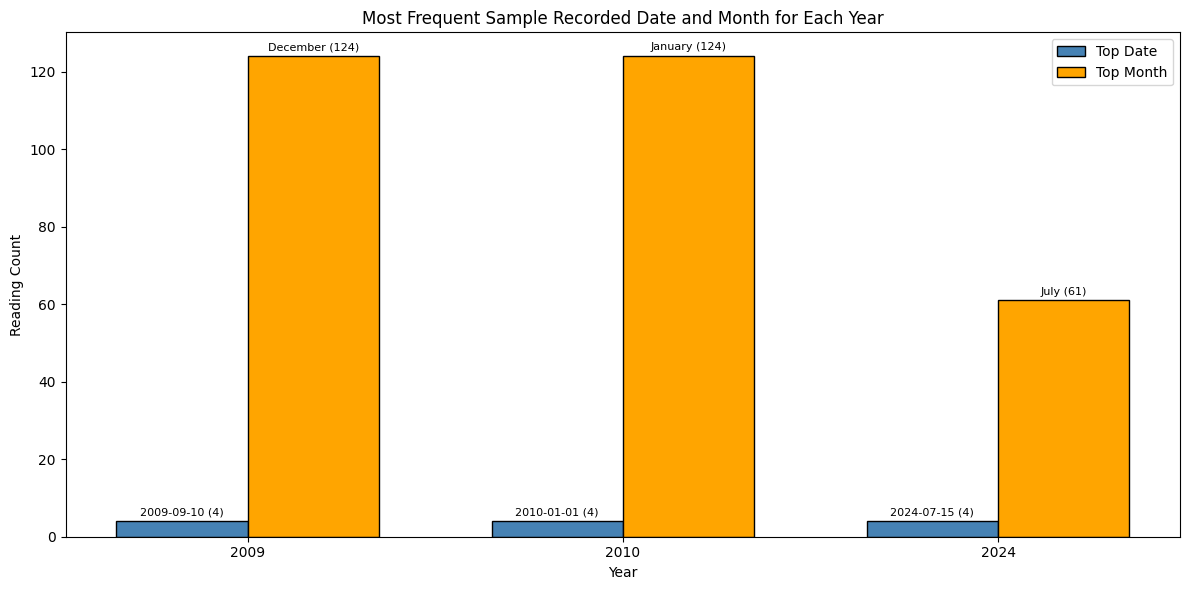

In [40]:
month_map = {
    1: "January",   2: "February", 3: "March",     4: "April",
    5: "May",       6: "June",     7: "July",      8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

years = top_df['year'].astype(str).tolist()
top_date_counts  = top_df['top_date_count'].tolist()
top_month_counts = top_df['top_month_count'].tolist()
top_dates        = top_df['top_date'].tolist()
top_months       = [month_map[m] for m in top_df['top_month']]

x = np.arange(len(years))
bar_width = 0.35

plt.figure(figsize=(12,6))

# top date
plt.bar(x - bar_width/2, top_date_counts, bar_width, 
        label='Top Date', color='steelblue', edgecolor='black')

# top month
plt.bar(x + bar_width/2, top_month_counts, bar_width,
        label='Top Month', color='orange', edgecolor='black')

# Annotate bars
for i in range(len(years)):
    plt.text(
        x[i] - bar_width/2, top_date_counts[i] + 1,
        f"{top_dates[i]} ({top_date_counts[i]})",
        ha='center', va='bottom', fontsize=8
    )
    plt.text(
        x[i] + bar_width/2, top_month_counts[i] + 1,
        f"{top_months[i]} ({top_month_counts[i]})",
        ha='center', va='bottom', fontsize=8
    )

plt.xticks(x, years)
plt.xlabel("Year")
plt.ylabel("Reading Count")
plt.title("Most Frequent Sample Recorded Date and Month for Each Year")
plt.legend()

plt.tight_layout()
plt.show()
